In [4]:
l = ["sumit", "ravi", "sanjay", "vijay"]

my_iter = iter(l)

next(my_iter)

'sumit'

In [5]:
next(my_iter)

'ravi'

In [6]:
next(my_iter)

'sanjay'

## Multi Modal Model (Images + Text (Caption))

In [1]:
!pip install -q datasets
# Libarary to download the datasets from the hugging face dataset platform

In [2]:
from datasets import load_dataset # will help me get a particular dataset from the hugging face platform
import matplotlib.pyplot as plt # will help me to visulise that.

dataset = load_dataset("Bingsu/Cat_and_Dog", split = "train", streaming=True)
# by default the load_dataset will download all the images in the split
# which is not optimised for our RAM
# so we stream, which will enable us to ask for a batch of Images at a time
# so if the batch size is 32, this will return me 32 images which I will provide to my alogirthm to learn from
# and then will flush it out from my RAM to load another batch of images.

README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/753 [00:00<?, ?B/s]

In [7]:
iterator = iter(dataset)
sample = next(iterator)

In [13]:
sample

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=300x280>,
 'labels': 0}

In [9]:
image = sample['image']
label = sample['labels']

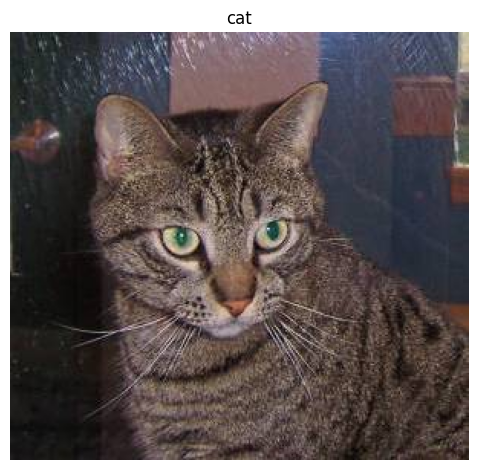

In [11]:
label_name = "cat" if label==0 else "dog"
plt.imshow(image)
plt.title(label_name)
plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:
import torch
import torch.nn as nn # this provides all the methods to train a neural network using pytorch framework
import torch.optim as optim # this provides us with the optimizer
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms # pytorch module to work with images
from transformers import AutoTokenizer # transformers is the hugging face library # AutoTokenizer help us download a pre trained tokenzier
from datasets import load_dataset # datasets is the hugging face libaray, load_dataset will help us download the data

- Class name has to be in pascal case
- No space between the words
- every word starts with a capital letter

In [15]:
# Buffer Data Pipeline

# Custom Dataset Class
# This will help us define a block
# within which I can define all the preprocessing step for the input data
# which is registered within the pytorch framework


img_transform = transforms.Compose(
    [transforms.Resize((128,128)),
     transforms.ToTensor(),
     transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5,0.5, 0.5])]
)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

class MultimodalCatDog(Dataset):
  def __init__(self, hf_dataset, tokenizer, transforms):
    self.hf_dataset = hf_dataset
    self.tokenizer = tokenizer
    self.transforms = transforms

  def __len__(self):
    return len(self.hf_dataset)

  def __getitem__(self, idx):
    item = self.hf_dataset[idx]

    # image process
    image = item['image'].convert('RGB')
    pixel_vales = self.transforms(image)

    # text process
    if item['labels']==0:
      text = "A photo of a cat"
    else:
      text = "A photo of a dog"

    tokens = self.tokenizer(
        text,
        padding = "max_length",
        max_length = 20,
        truncation = True,
        return_tensors = "pt"
    )

    return {
        "pixel_values": pixel_vales,
        "input_ids": tokens['input_ids'].squeeze(),
        "labels": torch.tensor(item['labels'], dtype = torch.long)
    }

full_dataset = load_dataset("Bingsu/Cat_and_Dog", split = "train", streaming=True)
mini_dataset = list(full_dataset.take(1000))

train_ds = MultimodalCatDog(mini_dataset, tokenizer, img_transform)
train_loader = DataLoader(train_ds, batch_size = 32, shuffle = True)


In [18]:
class TwoTowerClassifier(nn.Module):

  def __init__(self):
      super().__init__()


      # Text Block
      self.text_emb = nn.Embedding(30522, 64)
      self.text_fc = nn.Linear(64,32)

      # Image Block
      self.img_cov = nn.Sequential(
          nn.Conv2d(3,16,kernel_size = 3, padding = 1), # 3 channels, 16 feature maps as output and padding = 1 ensure the output feature map is of same size as input image.
          nn.ReLU(),
          nn.MaxPool2d(2),
          nn.Conv2d(16,32, kernel_size = 3, padding = 1),
          nn.ReLU(),
          nn.MaxPool2d(2),
          nn.Flatten()
      )

      self.img_fc = nn.Linear(32*32*32, 128)


      self.classifier = nn.Sequential(
          nn.Linear(128+32, 64),
          nn.ReLU(),
          nn.Linear(64, 2)
      )

  def forward(self, pixel_values, input_ids):
    text_emb = self.text_emb(input_ids).mean(dim=1)
    x_text = self.text_fc(text_emb)

    x_img = self.img_cov(pixel_values)
    x_img = self.img_fc(x_img)

    combined = torch.cat([x_text, x_img], dim = 1)
    return self.classifier(combined)

model = TwoTowerClassifier()

In [20]:
## Train Loop

optimizer = optim.Adam(model.parameters(), lr = 0.001) # optimizer will help us update the weight/paramters during the backward prop.
loss = nn.CrossEntropyLoss()

for epoch in range(5):
  total_loss = 0
  correct = 0
  total = 0

  for batch in train_loader:
    imgs = batch['pixel_values']
    texts = batch['input_ids']
    labels = batch['labels'] # ---> [[1]] [[0]]

    optimizer.zero_grad()
    outputs = model(imgs, texts)
    los = loss(outputs, labels)
    los.backward()
    optimizer.step()

    total_loss += los.item()
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  avg_loss = total_loss/len(train_loader)
  accuracy = 100*correct/total
  print(f"Epoch {epoch+1}/5 | Loss: {avg_loss:.4f} | Accouracy: {accuracy: .2f}%")


Epoch 1/5 | Loss: 0.0000 | Accouracy:  100.00%
Epoch 2/5 | Loss: 0.0000 | Accouracy:  100.00%
Epoch 3/5 | Loss: 0.0000 | Accouracy:  100.00%
Epoch 4/5 | Loss: 0.0000 | Accouracy:  100.00%
Epoch 5/5 | Loss: 0.0000 | Accouracy:  100.00%


In [21]:
sample = next(iter(train_loader))
# my input url

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

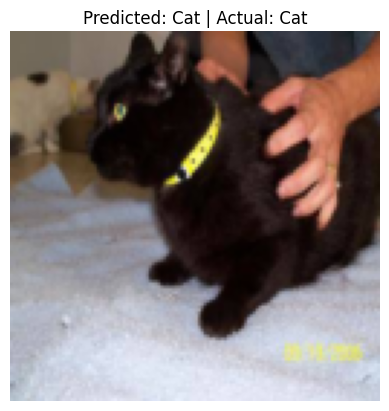

In [22]:
model.eval() # will set the model to infer. Now we are not going to train it.

with torch.no_grad():
  output = sample['pixel_values'], sample['input_ids']
  logit = model(sample['pixel_values'], sample['input_ids'])
  prob = torch.softmax(logit, dim = 1)
  pred = torch.argmax(prob, dim = 1)

# (h,w,c) tensor
# (c,h,w) numpy
img = sample['pixel_values'][0].permute(1,2,0).numpy()
img = img*0.5 + 0.5

pred_label = "Dog" if pred[0].item()==1 else "Cat"
actual_label = "Dog" if sample['labels'][0].item()==1 else "Cat"

plt.imshow(img)
plt.title(f"Predicted: {pred_label} | Actual: {actual_label}")
plt.axis('off')